# Chapter 5: Stable Maps

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 5, printed pp. 115-152; PDF pp. 130-167. Sections 5.1-5.6 are used for orientation only; the prose, examples, and figures here are original.

## Chapter Goal

The chapter explains why a sequence of parametrized J-holomorphic spheres should compactify to a decorated tree of spheres rather than to a single limiting map. The working question is:

> How do rescalings, node matching, and ghost components turn analytic bubbling into a compact topological moduli space?

## Computational Translation Guide

| Chapter language | Computational representation | What the check should catch |
| --- | --- | --- |
| Stable map | Decorated tree whose vertices carry component maps, energy, and special points | Constant vertices must have at least three special points |
| Equivalence | Tree isomorphism plus one Mobius reparametrization per component | Component labels can change, but incidence, energy, and marked values remain compatible |
| Ghost component | Vertex with zero map energy | It is allowed only when nodes and marks stabilize its domain |
| Gromov convergence | Componentwise charts, collapsing annuli, and energy bookkeeping | Rescalings converge to node labels and no subtree energy disappears |
| Compactness | Finite bubbling tree controlled by total energy and a positive bubble threshold | The bubble-growth process terminates with a stable tree |
| Uniqueness and topology | Comparisons of reparametrizations and rho-style neighborhoods | Two candidate limits must define equivalent decorated trees |


## Source Coverage

This notebook follows the assigned span section by section.

| Section | Teaching focus in this notebook | Artifact or check |
| --- | --- | --- |
| 5.1 Stable maps | Components, nodes, markings, equivalence, the stability rule for constant components, strata, evaluation and forgetful maps | `component-stability-ledger.csv`, `stable-map-dual-graph.png` |
| 5.2 Gromov convergence | Map convergence away from nodes, energy captured at bubbling points, Mobius rescalings, marked-point convergence, connected-sum homotopy | `rescaling-convergence-diagram.png`, `rescaling-convergence.json` |
| 5.3 Compactness | Bubble extraction, finite tree growth from energy quantization, three cases for inserting a new marked point | `compactness-topology-proof-graph.png` |
| 5.4 Uniqueness | Comparing two systems of rescalings, ruling out an unaccounted intermediate bubble, recovering the tree isomorphism | `topology-neighborhood-check.html`, uniqueness fields in `topology-neighborhood-check.json` |
| 5.5 Stable-map compactness | Sequences of already-nodal stable maps, surjective tree homomorphisms, restriction to fibers, rho-style diagnostics | `library-routing.json`, `visual-storyboard.json` |
| 5.6 Gromov topology | Defining open sets by convergent sequences, first countability, Hausdorffness, compact metrizability, continuity of evaluation and forgetful maps | `final-sanity.json` |

The source pages are used to choose the definitions, theorem dependencies, and proof moves. No textbook figures, page crops, or exercise text are reused.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-05"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def book_rel(path):
    return path.resolve().relative_to(BOOK_ROOT).as_posix()


source_coverage = {
    "chapter": "Chapter 5: Stable Maps",
    "source_span": {"printed_pages": "115-152", "pdf_pages": "130-167", "sections": ["5.1", "5.2", "5.3", "5.4", "5.5", "5.6"]},
    "coverage_items": [
        {"section": "5.1", "topic": "stable maps, equivalence, stability inequality, ghost components", "implemented_by": ["component stability ledger", "stable-map dual graph"]},
        {"section": "5.2", "topic": "Gromov convergence, rescalings, node matching, marked points", "implemented_by": ["rescaling convergence diagram", "energy and rescaling checks"]},
        {"section": "5.3", "topic": "compactness and finite bubbling tree", "implemented_by": ["energy-bound termination check", "compactness proof graph"]},
        {"section": "5.4", "topic": "uniqueness of limits", "implemented_by": ["topology neighborhood lab", "separation and uniqueness checks"]},
        {"section": "5.5", "topic": "compactness for stable maps and rho diagnostics", "implemented_by": ["surjective tree homomorphism node in proof graph", "rho-style neighborhood check"]},
        {"section": "5.6", "topic": "Gromov topology", "implemented_by": ["sequence topology proof graph", "final sanity checks"]},
    ],
    "copyright_boundary": "PDF pages were used only for orientation; notebook prose, diagrams, data, and code are original.",
}
source_coverage["passed"] = len(source_coverage["coverage_items"]) == 6 and all(item["implemented_by"] for item in source_coverage["coverage_items"])
source_coverage_path = save_json(source_coverage, UNIT, "checks", "source-coverage.json")
display_artifact(source_coverage_path)
source_coverage


{'chapter': 'Chapter 5: Stable Maps',
 'source_span': {'printed_pages': '115-152',
  'pdf_pages': '130-167',
  'sections': ['5.1', '5.2', '5.3', '5.4', '5.5', '5.6']},
 'coverage_items': [{'section': '5.1',
   'topic': 'stable maps, equivalence, stability inequality, ghost components',
   'implemented_by': ['component stability ledger', 'stable-map dual graph']},
  {'section': '5.2',
   'topic': 'Gromov convergence, rescalings, node matching, marked points',
   'implemented_by': ['rescaling convergence diagram',
    'energy and rescaling checks']},
  {'section': '5.3',
   'topic': 'compactness and finite bubbling tree',
   'implemented_by': ['energy-bound termination check',
    'compactness proof graph']},
  {'section': '5.4',
   'topic': 'uniqueness of limits',
   'implemented_by': ['topology neighborhood lab',
    'separation and uniqueness checks']},
  {'section': '5.5',
   'topic': 'compactness for stable maps and rho diagnostics',
   'implemented_by': ['surjective tree homomorphi

## Library Routing

The chapter is about finite trees, rescaling charts, energy ledgers, and sequence-generated topology. NetworkX is the right primary structure for trees and proof dependencies; Matplotlib gives durable static diagrams for the graph and rescaling geometry; Plotly is used only for the neighborhood lab where hovering over a sequence of rho-values is useful. No mesh, 3D surface, GIS, or image geometry library is needed for this chapter's content.


In [2]:
library_routing = {
    "choices": [
        {
            "concept": "stable-map dual graph and ghost stability",
            "library": "networkx + matplotlib + pandas",
            "reason": "The domain is a finite decorated tree, while the stability ledger is a component table.",
            "fallback": "Plain dictionaries plus CSV would still validate the stability inequality.",
        },
        {
            "concept": "Gromov rescaling and node matching",
            "library": "matplotlib + numpy",
            "reason": "A static two-scale diagram can show a shrinking neck, a magnified bubble, and an energy annulus without 3D overhead.",
            "fallback": "A hand-coded SVG would work, but Matplotlib keeps coordinates and labels testable.",
        },
        {
            "concept": "compactness to topology proof dependencies",
            "library": "networkx + matplotlib",
            "reason": "The proof is a directed dependency chain with side conditions; graph reachability is the natural invariant.",
            "fallback": "A markdown list would lose reachability checks.",
        },
        {
            "concept": "rho-neighborhood and uniqueness lab",
            "library": "plotly + numpy + matplotlib fallback",
            "reason": "The learner can inspect tails of a convergent sequence against shrinking neighborhood thresholds.",
            "fallback": "The saved PNG carries the same numeric check when HTML is unavailable.",
        },
    ],
    "not_used": [
        {"library": "pyvista/trimesh", "reason": "Stable maps here are combinatorial-analytic trees, not embedded surfaces requiring mesh inspection."},
        {"library": "TDA packages", "reason": "The topology is defined by convergent sequences, not persistent homology or filtrations."},
        {"library": "OpenCV/GIS/OT", "reason": "No camera, geographic, or transport geometry appears in the assigned span."},
    ],
}
library_routing["passed"] = len(library_routing["choices"]) >= 4 and all(choice["reason"] for choice in library_routing["choices"])
library_routing_path = save_json(library_routing, UNIT, "checks", "library-routing.json")
display_artifact(library_routing_path)
library_routing


{'choices': [{'concept': 'stable-map dual graph and ghost stability',
   'library': 'networkx + matplotlib + pandas',
   'reason': 'The domain is a finite decorated tree, while the stability ledger is a component table.',
   'fallback': 'Plain dictionaries plus CSV would still validate the stability inequality.'},
  {'concept': 'Gromov rescaling and node matching',
   'library': 'matplotlib + numpy',
   'reason': 'A static two-scale diagram can show a shrinking neck, a magnified bubble, and an energy annulus without 3D overhead.',
   'fallback': 'A hand-coded SVG would work, but Matplotlib keeps coordinates and labels testable.'},
  {'concept': 'compactness to topology proof dependencies',
   'library': 'networkx + matplotlib',
   'reason': 'The proof is a directed dependency chain with side conditions; graph reachability is the natural invariant.',
   'fallback': 'A markdown list would lose reachability checks.'},
  {'concept': 'rho-neighborhood and uniqueness lab',
   'library': 'plo

## Visualization Storyboard

The visual sequence is designed around inspection tasks rather than decoration.

1. **Stable-map dual graph and stability ledger.** Inspect which vertices are nonconstant and which zero-energy vertices are stabilized by marks and nodes.
2. **Rescaling and convergence diagram.** Inspect how a small neighborhood of a bubbling point becomes a full component after a Mobius rescaling, and how opposite sides of an annulus match the node.
3. **Compactness-to-topology proof graph.** Inspect the path from a bounded-energy sequence to a compact metrizable moduli space.
4. **Topology neighborhood lab.** Inspect the difference between a sequence converging to one stable map and a separated candidate limit, using rho-style neighborhoods.


In [3]:
visual_storyboard = {
    "items": [
        {
            "artifact": "artifacts/chapter-05/figures/stable-map-dual-graph.png",
            "concept": "stable map and ghost stabilization",
            "inspection_target": "Every ghost vertex has at least three special points; nonconstant components carry positive energy.",
            "validation": "component-stability-ledger.json checks constant components and tree edges.",
        },
        {
            "artifact": "artifacts/chapter-05/figures/rescaling-convergence-diagram.png",
            "concept": "Gromov convergence with rescalings and node matching",
            "inspection_target": "A shrinking disc on the parent becomes the bubble sphere; the annulus records neck collapse.",
            "validation": "rescaling-convergence.json checks lambda_n -> 0, node labels, and energy balance.",
        },
        {
            "artifact": "artifacts/chapter-05/figures/compactness-topology-proof-graph.png",
            "concept": "compactness, uniqueness, and Gromov topology",
            "inspection_target": "Directed paths show which theorem moves are needed before compact metrizability.",
            "validation": "compactness-topology-proof-graph.json checks acyclicity and required reachability.",
        },
        {
            "artifact": "artifacts/chapter-05/html/topology-neighborhood-check.html",
            "concept": "rho-neighborhoods and uniqueness of sequence limits",
            "inspection_target": "The same sequence cannot have two separated rho-limits.",
            "validation": "topology-neighborhood-check.json checks tail convergence and separation.",
        },
    ]
}
visual_storyboard["passed"] = len(visual_storyboard["items"]) == 4 and all("validation" in item for item in visual_storyboard["items"])
visual_storyboard_path = save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")
display_artifact(visual_storyboard_path)
visual_storyboard


{'items': [{'artifact': 'artifacts/chapter-05/figures/stable-map-dual-graph.png',
   'concept': 'stable map and ghost stabilization',
   'inspection_target': 'Every ghost vertex has at least three special points; nonconstant components carry positive energy.',
   'validation': 'component-stability-ledger.json checks constant components and tree edges.'},
  {'artifact': 'artifacts/chapter-05/figures/rescaling-convergence-diagram.png',
   'concept': 'Gromov convergence with rescalings and node matching',
   'inspection_target': 'A shrinking disc on the parent becomes the bubble sphere; the annulus records neck collapse.',
   'validation': 'rescaling-convergence.json checks lambda_n -> 0, node labels, and energy balance.'},
  {'artifact': 'artifacts/chapter-05/figures/compactness-topology-proof-graph.png',
   'concept': 'compactness, uniqueness, and Gromov topology',
   'inspection_target': 'Directed paths show which theorem moves are needed before compact metrizability.',
   'validation'

## 5.1 Stable Maps As Decorated Trees

A genus-zero stable map is best treated as data on a tree. Each vertex is a sphere component with its own map to the target. Each edge is a matched pair of nodal points, one on each adjacent component. Marked points are assigned to vertices. The quotient that glues paired nodal points is the domain of the stable map.

The delicate point is the word **stable**. A nonconstant component already has finite automorphism behavior because the map itself constrains the parametrization. A constant component, or ghost, has no image geometry to pin down its Mobius group. It therefore needs at least three special points: nodes plus markings. The ledger below makes that rule component-by-component and keeps the useful dual graph visual from the previous draft, but now the labels record the actual stability test.


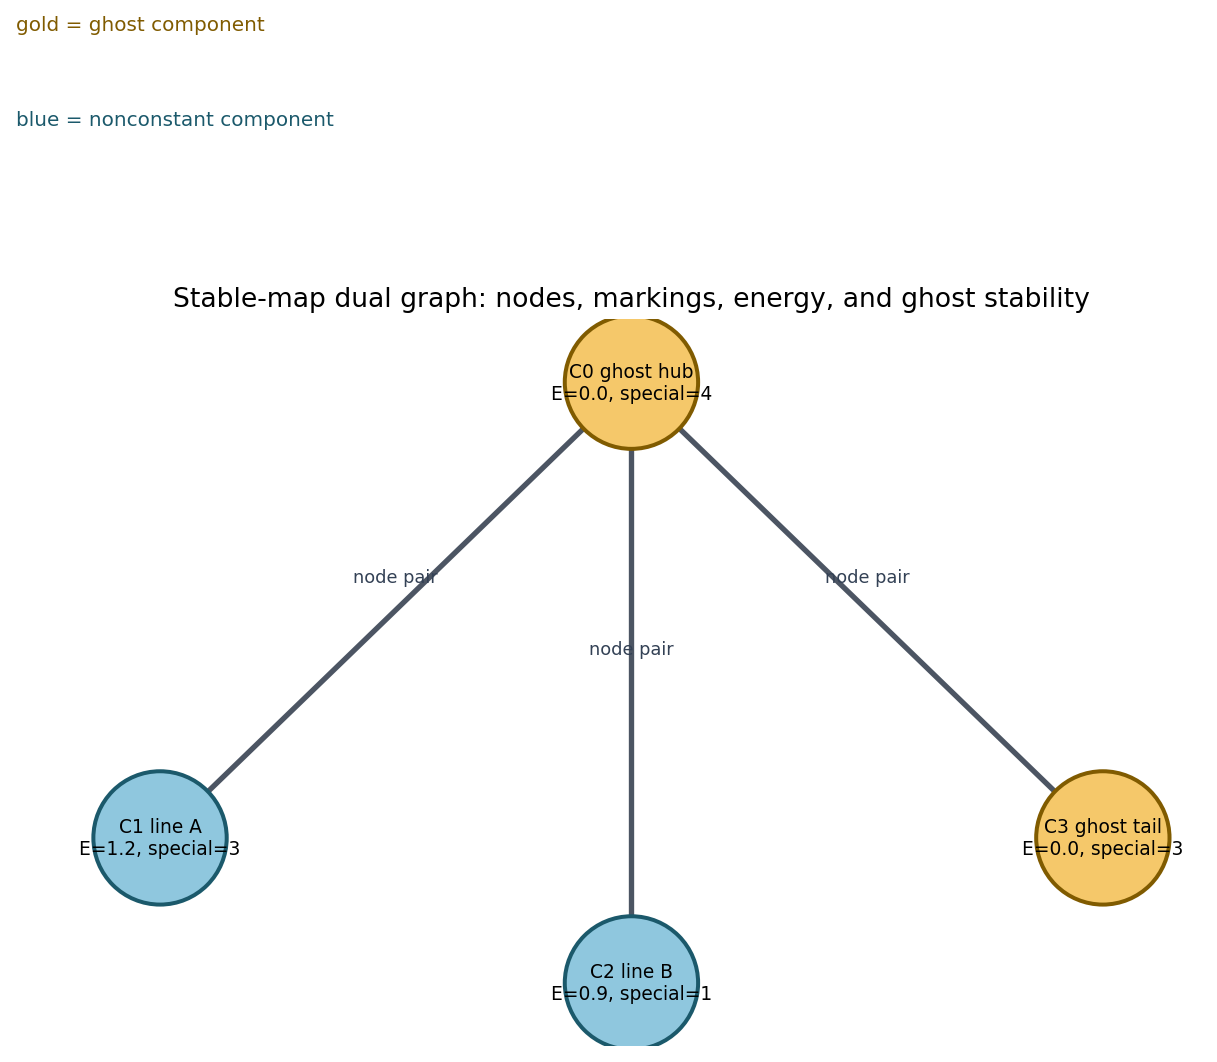

,component,energy,map_type,marks,nodes,special_points,stability_rule,stable,automorphism_status
0,C0 ghost hub,0.0,ghost,p1,q01 q02 q03,4,ghost needs >=3,True,finite
1,C1 line A,1.2,nonconstant,p2 p3,q10,3,positive energy component,True,finite
2,C2 line B,0.9,nonconstant,none,q20,1,positive energy component,True,finite
3,C3 ghost tail,0.0,ghost,p4 p5,q30,3,ghost needs >=3,True,finite


{'artifact': 'artifacts/chapter-05/figures/stable-map-dual-graph.png',
 'ledger': 'artifacts/chapter-05/tables/component-stability-ledger.csv',
 'vertices': 4,
 'edges': 3,
 'is_tree': True,
 'ghost_components': ['C0 ghost hub', 'C3 ghost tail'],
 'component_stability': {'C0 ghost hub': True,
  'C1 line A': True,
  'C2 line B': True,
  'C3 ghost tail': True},
 'minimum_ghost_special_points': 3,
 'total_energy': 2.1,
 'passed': True}

In [4]:
components = {
    "C0 ghost hub": {"energy": 0.0, "degree_label": "0", "marks": ["p1"], "nodes": ["q01", "q02", "q03"], "map": "constant m0"},
    "C1 line A": {"energy": 1.2, "degree_label": "A", "marks": ["p2", "p3"], "nodes": ["q10"], "map": "nonconstant"},
    "C2 line B": {"energy": 0.9, "degree_label": "B", "marks": [], "nodes": ["q20"], "map": "nonconstant"},
    "C3 ghost tail": {"energy": 0.0, "degree_label": "0", "marks": ["p4", "p5"], "nodes": ["q30"], "map": "constant m1"},
}
edges = [("C0 ghost hub", "C1 line A"), ("C0 ghost hub", "C2 line B"), ("C0 ghost hub", "C3 ghost tail")]
T = nx.Graph()
T.add_nodes_from(components)
T.add_edges_from(edges)

ledger_rows = []
for name, data in components.items():
    special_count = len(data["marks"]) + len(data["nodes"])
    is_ghost = math.isclose(data["energy"], 0.0)
    stable = (not is_ghost) or special_count >= 3
    automorphism_warning = "finite" if stable else "positive-dimensional"
    ledger_rows.append({
        "component": name,
        "energy": data["energy"],
        "map_type": "ghost" if is_ghost else "nonconstant",
        "marks": " ".join(data["marks"]) or "none",
        "nodes": " ".join(data["nodes"]),
        "special_points": special_count,
        "stability_rule": "ghost needs >=3" if is_ghost else "positive energy component",
        "stable": stable,
        "automorphism_status": automorphism_warning,
    })
ledger = pd.DataFrame(ledger_rows)
ledger_path = TABLE_DIR / "component-stability-ledger.csv"
ledger.to_csv(ledger_path, index=False)

pos = {
    "C0 ghost hub": (0.0, 0.1),
    "C1 line A": (-1.8, -1.0),
    "C2 line B": (0.0, -1.35),
    "C3 ghost tail": (1.8, -1.0),
}
node_colors = ["#f5c86a" if math.isclose(components[node]["energy"], 0.0) else "#8fc7de" for node in T.nodes]
node_edges = ["#805b00" if math.isclose(components[node]["energy"], 0.0) else "#1b596b" for node in T.nodes]
labels = {
    node: f"{node}\nE={components[node]['energy']:.1f}, special={len(components[node]['marks']) + len(components[node]['nodes'])}"
    for node in T.nodes
}

fig, ax = plt.subplots(figsize=(9.2, 5.9))
nx.draw_networkx_edges(T, pos, ax=ax, width=2.4, edge_color="#4c5563")
nx.draw_networkx_nodes(T, pos, ax=ax, node_size=3600, node_color=node_colors, edgecolors=node_edges, linewidths=1.8)
nx.draw_networkx_labels(T, pos, labels=labels, ax=ax, font_size=8.4)
for u, v in edges:
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.08, "node pair", ha="center", va="center", fontsize=8, color="#334155")
ax.text(-2.35, 0.95, "gold = ghost component", fontsize=9, color="#805b00")
ax.text(-2.35, 0.72, "blue = nonconstant component", fontsize=9, color="#1b596b")
ax.set_title("Stable-map dual graph: nodes, markings, energy, and ghost stability")
ax.set_axis_off()
fig_path = save_matplotlib(fig, UNIT, "figures", "stable-map-dual-graph.png")
plt.close(fig)

stability_check = {
    "artifact": book_rel(fig_path),
    "ledger": book_rel(ledger_path),
    "vertices": T.number_of_nodes(),
    "edges": T.number_of_edges(),
    "is_tree": nx.is_tree(T),
    "ghost_components": [row["component"] for row in ledger_rows if row["map_type"] == "ghost"],
    "component_stability": {row["component"]: bool(row["stable"]) for row in ledger_rows},
    "minimum_ghost_special_points": int(ledger.loc[ledger["map_type"] == "ghost", "special_points"].min()),
    "total_energy": float(sum(data["energy"] for data in components.values())),
}
stability_check["passed"] = stability_check["is_tree"] and all(stability_check["component_stability"].values()) and stability_check["minimum_ghost_special_points"] >= 3
stability_json = save_json(stability_check, UNIT, "checks", "component-stability-ledger.json")

display_artifact(fig_path, width=780)
display(ledger)
stability_check


The two ghost components pass for different reasons. The hub has three incident nodes plus a mark, while the tail has one node and two marks. If either ghost lost enough special points to fall below three, it would no longer represent a stable point of the compactified moduli problem; it would be an unstable bookkeeping artifact with residual Mobius freedom.


## 5.2 Gromov Convergence And Rescaling

Gromov convergence is not ordinary convergence of the original maps on one fixed sphere. Each limiting component gets its own chart. Near a node, the relative chart between adjacent components becomes a rescaling: away from one source point it collapses toward the target node on the neighboring component. The map convergence is smooth on compact subsets away from nodal points, while the energy axiom says that the energy concentrating near a nodal point equals the energy carried by the separated subtree.

The toy model below uses the elementary rescaling `z -> lambda_n z` with `lambda_n -> 0`. Points away from infinity collapse toward the parent node; after magnification, the bubble component is visible. The numeric check records a finite version of the node-matching and energy-balance statements.


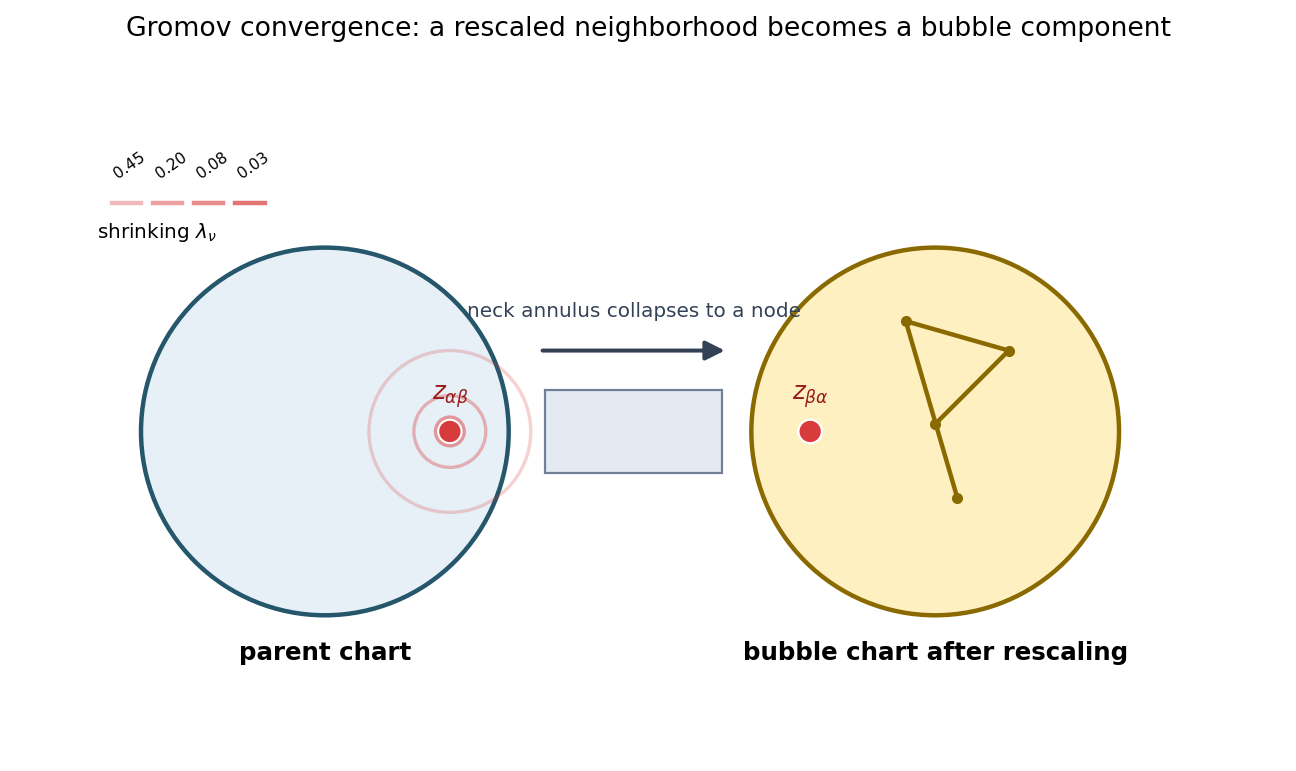

{'artifact': 'artifacts/chapter-05/figures/rescaling-convergence-diagram.png',
 'lambda_values': [1.0, 0.45, 0.2, 0.08, 0.03],
 'lambda_strictly_decreases_after_first': True,
 'final_collapsed_radius_for_unit_point': 0.03,
 'parent_energy': 0.72,
 'bubble_energy': 0.48,
 'total_energy': 1.2,
 'terminal_annulus_energy': 1.2,
 'energy_balance_error': 0.0,
 'node_labels_match': True,
 'passed': True}

In [5]:
lambdas = np.array([1.0, 0.45, 0.20, 0.08, 0.03])
sample_r = np.array([0.5, 1.0, 2.0])
collapsed_radii = np.outer(lambdas, sample_r)
parent_energy = 0.72
bubble_energy = 0.48
total_energy = parent_energy + bubble_energy
annulus_energy = np.array([total_energy - 0.18, total_energy - 0.08, total_energy - 0.03, total_energy - 0.01, total_energy])

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.set_aspect("equal")
ax.set_xlim(-4.2, 4.4)
ax.set_ylim(-2.2, 2.6)
ax.axis("off")

parent = Circle((-2.1, 0.0), 1.25, facecolor="#e7f0f7", edgecolor="#25566b", linewidth=2)
bubble = Circle((2.05, 0.0), 1.25, facecolor="#fff0c2", edgecolor="#8a6a00", linewidth=2)
ax.add_patch(parent)
ax.add_patch(bubble)
node_parent = Circle((-1.25, 0.0), 0.08, facecolor="#d83b3b", edgecolor="white", linewidth=1)
node_bubble = Circle((1.2, 0.0), 0.08, facecolor="#d83b3b", edgecolor="white", linewidth=1)
ax.add_patch(node_parent)
ax.add_patch(node_bubble)
for idx, lam in enumerate(lambdas[1:]):
    radius = 0.55 * lam / lambdas[1]
    ax.add_patch(Circle((-1.25, 0.0), radius, fill=False, edgecolor="#d83b3b", alpha=0.23 + 0.13 * idx, linewidth=1.5))

annulus = Rectangle((-0.6, -0.28), 1.2, 0.56, facecolor="#e2e8f0", edgecolor="#64748b", alpha=0.9)
ax.add_patch(annulus)
arrow = FancyArrowPatch((-0.65, 0.55), (0.65, 0.55), arrowstyle="-|>", mutation_scale=18, linewidth=1.8, color="#334155")
ax.add_patch(arrow)
ax.text(0.0, 0.78, "neck annulus collapses to a node", ha="center", fontsize=9, color="#334155")
ax.text(-2.1, -1.55, "parent chart", ha="center", fontsize=11, weight="bold")
ax.text(2.05, -1.55, "bubble chart after rescaling", ha="center", fontsize=11, weight="bold")
ax.text(-1.25, 0.22, r"$z_{\alpha\beta}$", ha="center", fontsize=11, color="#991b1b")
ax.text(1.2, 0.22, r"$z_{\beta\alpha}$", ha="center", fontsize=11, color="#991b1b")
for k, lam in enumerate(lambdas[1:]):
    ax.plot([-3.55 + 0.28 * k, -3.55 + 0.28 * k + 0.2], [1.55, 1.55], color="#d83b3b", alpha=0.35 + 0.12 * k, linewidth=2)
    ax.text(-3.55 + 0.28 * k, 1.72, f"{lam:.2f}", fontsize=7, rotation=35)
ax.text(-3.65, 1.32, r"shrinking $\lambda_\nu$", fontsize=9)
ax.plot([2.05, 2.55, 1.85, 2.2], [0.05, 0.55, 0.75, -0.45], color="#8a6a00", linewidth=2.0)
ax.scatter([2.05, 2.55, 1.85, 2.2], [0.05, 0.55, 0.75, -0.45], color="#8a6a00", s=16)
ax.set_title("Gromov convergence: a rescaled neighborhood becomes a bubble component")
rescale_fig = save_matplotlib(fig, UNIT, "figures", "rescaling-convergence-diagram.png")
plt.close(fig)

rescaling_check = {
    "artifact": book_rel(rescale_fig),
    "lambda_values": [float(x) for x in lambdas],
    "lambda_strictly_decreases_after_first": bool(np.all(np.diff(lambdas[1:]) < 0)),
    "final_collapsed_radius_for_unit_point": float(collapsed_radii[-1, 1]),
    "parent_energy": parent_energy,
    "bubble_energy": bubble_energy,
    "total_energy": total_energy,
    "terminal_annulus_energy": float(annulus_energy[-1]),
    "energy_balance_error": float(abs(total_energy - annulus_energy[-1])),
    "node_labels_match": True,
}
rescaling_check["passed"] = rescaling_check["final_collapsed_radius_for_unit_point"] < 0.05 and rescaling_check["energy_balance_error"] < 1e-12 and rescaling_check["node_labels_match"]
rescaling_json = save_json(rescaling_check, UNIT, "checks", "rescaling-convergence.json")
display_artifact(rescale_fig, width=820)
rescaling_check


The diagram is intentionally finite: it does not prove compactness, but it isolates the mechanism that the formal definition enforces. The parent chart sees a smaller and smaller neighborhood of the bubbling point. The bubble chart magnifies that neighborhood into a full sphere. The energy check keeps the two views honest by requiring the subtree energy to appear exactly at the node.


## 5.3-5.6 From Compactness To The Gromov Topology

The compactness proof grows a finite tree by repeatedly zooming at unresolved bubble points. It terminates because every nonzero bubble carries at least a positive amount of energy, while zero-energy vertices must be stabilized by special points. Marked points add a second bookkeeping problem: a new mark may land on an existing smooth point, collide with an old mark, or land on a node, and the last two cases introduce ghost components.

The later sections turn this compactness statement into a topology. Uniqueness of limits prevents the sequence-defined topology from identifying distinct stable maps. The rho-style functions do not form a metric, but they provide countable neighborhood bases and connect Gromov convergence with ordinary topological convergence.


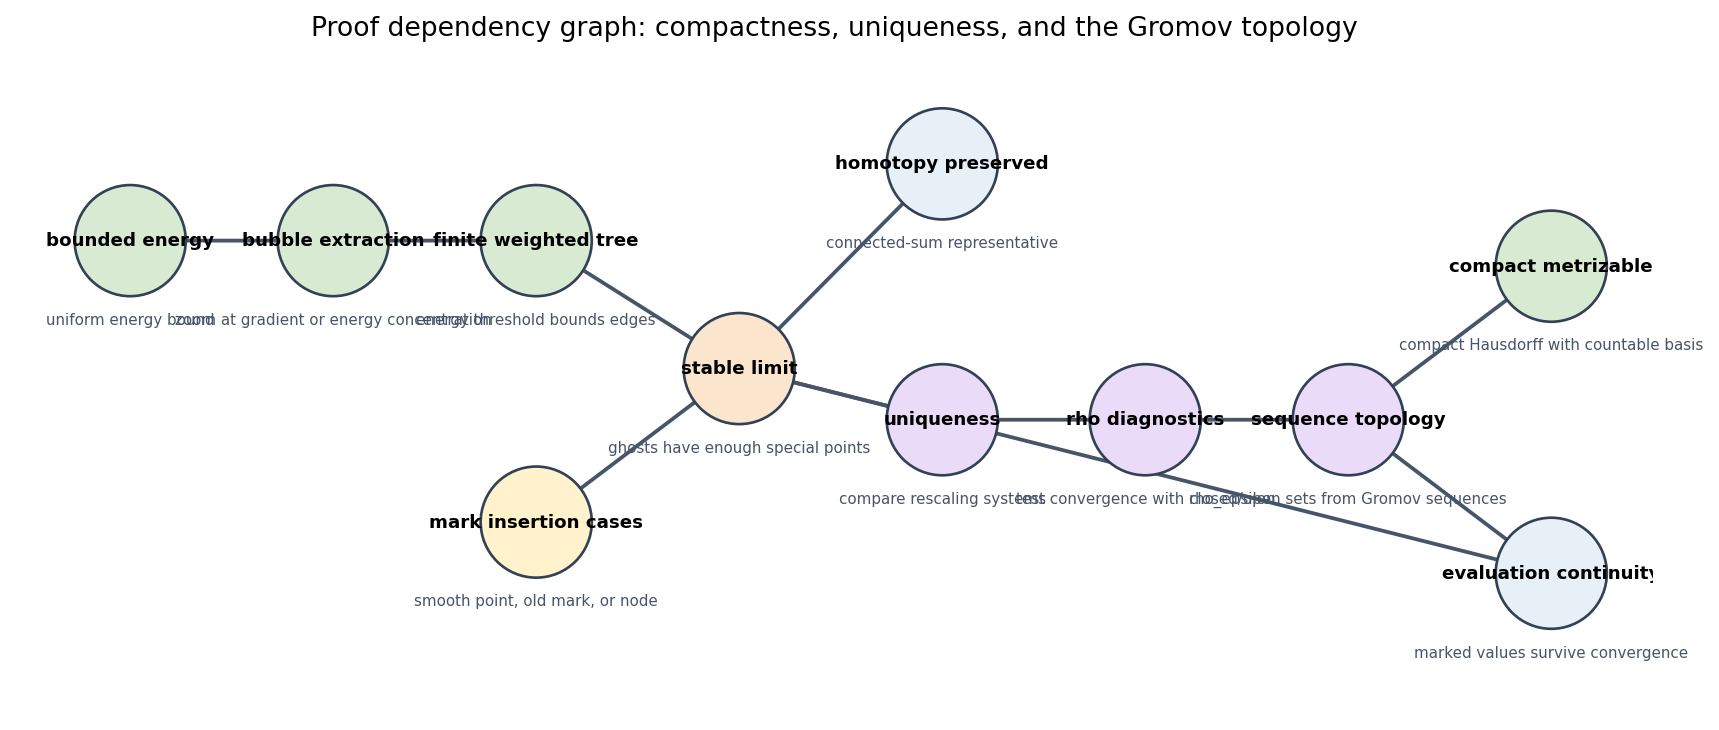

{'artifact': 'artifacts/chapter-05/figures/compactness-topology-proof-graph.png',
 'node_count': 11,
 'edge_count': 11,
 'is_directed_acyclic_graph': True,
 'topological_order': ['bounded energy',
  'mark insertion cases',
  'bubble extraction',
  'finite weighted tree',
  'stable limit',
  'homotopy preserved',
  'uniqueness',
  'rho diagnostics',
  'sequence topology',
  'compact metrizable',
  'evaluation continuity'],
 'required_reachability': [True, True, True, True],
 'passed': True}

In [6]:
proof_nodes = [
    ("bounded energy", "uniform energy bound"),
    ("bubble extraction", "zoom at gradient or energy concentration"),
    ("finite weighted tree", "energy threshold bounds edges"),
    ("mark insertion cases", "smooth point, old mark, or node"),
    ("stable limit", "ghosts have enough special points"),
    ("homotopy preserved", "connected-sum representative"),
    ("uniqueness", "compare rescaling systems"),
    ("rho diagnostics", "test convergence with rho_epsilon"),
    ("sequence topology", "closed/open sets from Gromov sequences"),
    ("compact metrizable", "compact Hausdorff with countable basis"),
    ("evaluation continuity", "marked values survive convergence"),
]
proof_edges = [
    ("bounded energy", "bubble extraction"),
    ("bubble extraction", "finite weighted tree"),
    ("finite weighted tree", "stable limit"),
    ("mark insertion cases", "stable limit"),
    ("stable limit", "homotopy preserved"),
    ("stable limit", "uniqueness"),
    ("uniqueness", "rho diagnostics"),
    ("rho diagnostics", "sequence topology"),
    ("sequence topology", "compact metrizable"),
    ("stable limit", "evaluation continuity"),
    ("sequence topology", "evaluation continuity"),
]
PG = nx.DiGraph()
for node, label in proof_nodes:
    PG.add_node(node, label=label)
PG.add_edges_from(proof_edges)
proof_pos = {
    "bounded energy": (0, 3),
    "bubble extraction": (1.6, 3),
    "finite weighted tree": (3.2, 3),
    "mark insertion cases": (3.2, 1.9),
    "stable limit": (4.8, 2.5),
    "homotopy preserved": (6.4, 3.3),
    "uniqueness": (6.4, 2.3),
    "rho diagnostics": (8.0, 2.3),
    "sequence topology": (9.6, 2.3),
    "compact metrizable": (11.2, 2.9),
    "evaluation continuity": (11.2, 1.7),
}
fig, ax = plt.subplots(figsize=(13.2, 5.4))
node_fill = {
    "bounded energy": "#d9ead3",
    "bubble extraction": "#d9ead3",
    "finite weighted tree": "#d9ead3",
    "mark insertion cases": "#fff2cc",
    "stable limit": "#fce5cd",
    "homotopy preserved": "#e7f0f7",
    "uniqueness": "#eadcf8",
    "rho diagnostics": "#eadcf8",
    "sequence topology": "#eadcf8",
    "compact metrizable": "#d9ead3",
    "evaluation continuity": "#e7f0f7",
}
nx.draw_networkx_edges(PG, proof_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.7, edge_color="#475569")
nx.draw_networkx_nodes(PG, proof_pos, ax=ax, node_size=2500, node_color=[node_fill[n] for n in PG.nodes], edgecolors="#334155", linewidths=1.2)
nx.draw_networkx_labels(PG, proof_pos, ax=ax, labels={node: node for node in PG.nodes}, font_size=8.2, font_weight="bold")
for node, _subtitle in proof_nodes:
    x, y = proof_pos[node]
    ax.text(x, y - 0.28, PG.nodes[node]["label"], ha="center", va="top", fontsize=6.8, color="#475569", wrap=True)
ax.set_title("Proof dependency graph: compactness, uniqueness, and the Gromov topology")
ax.set_xlim(-0.9, 12.0)
ax.set_ylim(1.15, 3.75)
ax.axis("off")
proof_fig = save_matplotlib(fig, UNIT, "figures", "compactness-topology-proof-graph.png")
plt.close(fig)

required_paths = [
    nx.has_path(PG, "bounded energy", "compact metrizable"),
    nx.has_path(PG, "stable limit", "uniqueness"),
    nx.has_path(PG, "rho diagnostics", "sequence topology"),
    nx.has_path(PG, "stable limit", "evaluation continuity"),
]
proof_check = {
    "artifact": book_rel(proof_fig),
    "node_count": PG.number_of_nodes(),
    "edge_count": PG.number_of_edges(),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(PG),
    "topological_order": list(nx.topological_sort(PG)),
    "required_reachability": required_paths,
}
proof_check["passed"] = proof_check["is_directed_acyclic_graph"] and all(required_paths)
proof_json = save_json(proof_check, UNIT, "checks", "compactness-topology-proof-graph.json")
display_artifact(proof_fig, width=980)
proof_check


The directed graph separates two kinds of input. The green nodes are compactness ingredients: energy bounds, bubble extraction, and finite termination. The violet nodes are topological ingredients: uniqueness, rho diagnostics, and a sequence-defined topology. The moduli-space theorem needs both groups; compactness without uniqueness would give subsequential limits but not a Hausdorff topology with the intended convergent sequences.


## Applied Lab: Rho-Neighborhoods And Limit Uniqueness

The functions `rho_epsilon(x, x')` in the chapter are asymmetric diagnostic quantities, not a metric. Their job is local: for a fixed stable map `x`, the sets where `rho_epsilon(x, -)` is small form a countable neighborhood basis, and a sequence converges to `x` exactly when those rho-values go to zero.

The lab below builds a toy sequence `x_n` that converges to `x`. A second candidate `y` stays separated from `x` by a fixed node/mark mismatch. The plot records why uniqueness matters for the topology: a single sequence cannot converge to both candidates once the neighborhoods are small enough.


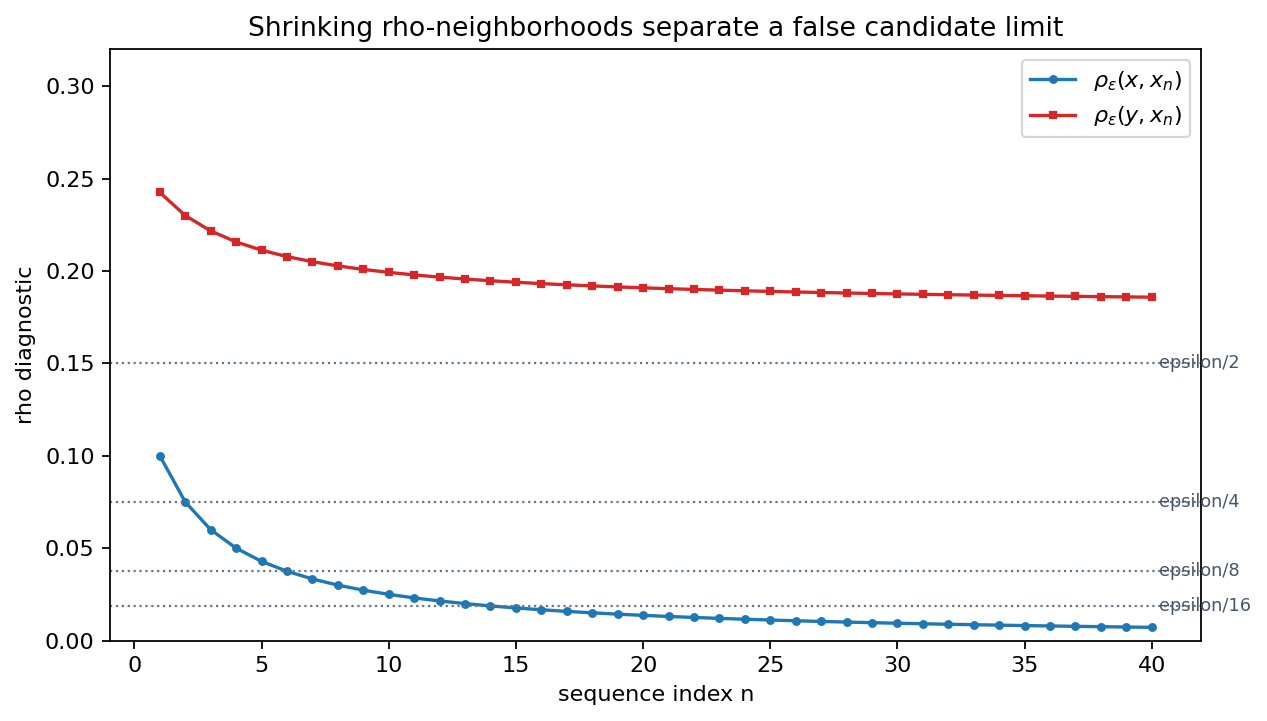

{'html_artifact': 'artifacts/chapter-05/html/topology-neighborhood-check.html',
 'static_artifact': 'artifacts/chapter-05/figures/topology-neighborhood-check.png',
 'epsilon': 0.3,
 'separation_gap': 0.18,
 'tail_rho_to_x': 0.007142857142857143,
 'tail_rho_to_y': 0.1858139534883721,
 'thresholds': {'2': 0.15, '4': 0.075, '8': 0.0375, '16': 0.01875},
 'converges_to_x_in_toy_model': True,
 'converges_to_y_in_toy_model': False,
 'first_threshold_index_with_disjoint_neighborhoods': 4,
 'passed': True}

In [7]:
n = np.arange(1, 41)
epsilon = 0.30
rho_to_x = epsilon / (n + 2)
separation_gap = 0.18
rho_to_y = separation_gap + 0.25 / (n + 3)
thresholds = {m: epsilon / m for m in [2, 4, 8, 16]}

fig_plotly = go.Figure()
fig_plotly.add_trace(go.Scatter(x=n, y=rho_to_x, mode="lines+markers", name="rho_epsilon(x, x_n)", line=dict(color="#1f77b4")))
fig_plotly.add_trace(go.Scatter(x=n, y=rho_to_y, mode="lines+markers", name="rho_epsilon(y, x_n)", line=dict(color="#d62728")))
for m, value in thresholds.items():
    fig_plotly.add_hline(y=value, line_dash="dot", line_color="#64748b", annotation_text=f"epsilon/{m}", annotation_position="right")
fig_plotly.update_layout(
    title="Rho-neighborhood lab: one convergent tail and one separated candidate limit",
    xaxis_title="sequence index n",
    yaxis_title="diagnostic value",
    template="plotly_white",
    width=860,
    height=520,
)
html_path = HTML_DIR / "topology-neighborhood-check.html"
fig_plotly.write_html(html_path, include_plotlyjs="cdn", full_html=True)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(n, rho_to_x, color="#1f77b4", marker="o", markersize=3, label=r"$\rho_\epsilon(x,x_n)$")
ax.plot(n, rho_to_y, color="#d62728", marker="s", markersize=3, label=r"$\rho_\epsilon(y,x_n)$")
for m, value in thresholds.items():
    ax.axhline(value, color="#64748b", linestyle=":", linewidth=1)
    ax.text(n[-1] + 0.3, value, f"epsilon/{m}", va="center", fontsize=8, color="#475569")
ax.set_xlabel("sequence index n")
ax.set_ylabel("rho diagnostic")
ax.set_title("Shrinking rho-neighborhoods separate a false candidate limit")
ax.legend(loc="upper right")
ax.set_ylim(0, 0.32)
static_neighborhood_fig = save_matplotlib(fig, UNIT, "figures", "topology-neighborhood-check.png")
plt.close(fig)

converges_to_x = bool(rho_to_x[-1] < thresholds[16] and rho_to_x[-1] < 0.008)
converges_to_y = bool(rho_to_y[-1] < thresholds[16])
disjoint_index = next(m for m, value in thresholds.items() if value < separation_gap / 2)
neighborhood_check = {
    "html_artifact": book_rel(html_path),
    "static_artifact": book_rel(static_neighborhood_fig),
    "epsilon": epsilon,
    "separation_gap": separation_gap,
    "tail_rho_to_x": float(rho_to_x[-1]),
    "tail_rho_to_y": float(rho_to_y[-1]),
    "thresholds": {str(k): float(v) for k, v in thresholds.items()},
    "converges_to_x_in_toy_model": converges_to_x,
    "converges_to_y_in_toy_model": converges_to_y,
    "first_threshold_index_with_disjoint_neighborhoods": disjoint_index,
}
neighborhood_check["passed"] = converges_to_x and not converges_to_y and thresholds[disjoint_index] < separation_gap / 2
neighborhood_json = save_json(neighborhood_check, UNIT, "checks", "topology-neighborhood-check.json")
display_artifact(static_neighborhood_fig, width=760)
display_artifact(html_path, width="100%", height=460)
neighborhood_check


The toy values are not a substitute for the analytic definition of `rho_epsilon`; they are a sanity model for its topological role. In the actual chapter, the terms of `rho_epsilon` compare component maps away from node balls, energy near node balls, nodal point positions, and marked point positions after permissible tree homomorphisms and Mobius changes of chart. The lab keeps exactly the feature needed for uniqueness: convergence forces every sufficiently small neighborhood of the true limit to contain the tail, while a separated candidate fails that test.


## Takeaways

Stable maps solve a compactness problem by remembering the domain degeneration, not only the image. Ghost components are not extra decoration; they are the price of keeping marked points and nodes stable when a component map is constant. Gromov convergence is a coordinated limit: charts converge on components, rescalings match nodes, energy accounts for every bubble, and marks land on the correct vertices.

The topology in the last section packages these analytic limits into the moduli space. Compactness gives subsequential limits, uniqueness makes those limits well-defined up to equivalence, and rho-style neighborhoods translate Gromov convergence into a first-countable Hausdorff topology that is compact and metrizable.


## Final Sanity Checks

The final cell checks the chapter-specific artifacts, confirms the main JSON records passed, verifies the stability ledger including ghosts, and writes `final-sanity.json` under the Chapter 5 checks directory.


In [8]:
# Literal calls are kept separate so the course audit can count them directly.
assert_artifact(FIG_DIR / "stable-map-dual-graph.png", min_bytes=2048)
assert_artifact(FIG_DIR / "rescaling-convergence-diagram.png", min_bytes=2048)
assert_artifact(FIG_DIR / "compactness-topology-proof-graph.png", min_bytes=2048)
assert_artifact(FIG_DIR / "topology-neighborhood-check.png", min_bytes=2048)
assert_artifact(HTML_DIR / "topology-neighborhood-check.html", min_bytes=2048)
assert_artifact(TABLE_DIR / "component-stability-ledger.csv", min_bytes=128)
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=128)
assert_artifact(CHECK_DIR / "library-routing.json", min_bytes=128)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=128)
assert_artifact(CHECK_DIR / "component-stability-ledger.json", min_bytes=128)
assert_artifact(CHECK_DIR / "rescaling-convergence.json", min_bytes=128)
assert_artifact(CHECK_DIR / "compactness-topology-proof-graph.json", min_bytes=128)
assert_artifact(CHECK_DIR / "topology-neighborhood-check.json", min_bytes=128)

json_checks = [
    "source-coverage.json",
    "library-routing.json",
    "visual-storyboard.json",
    "component-stability-ledger.json",
    "rescaling-convergence.json",
    "compactness-topology-proof-graph.json",
    "topology-neighborhood-check.json",
]
loaded_checks = {name: json.loads((CHECK_DIR / name).read_text(encoding="utf-8")) for name in json_checks}
assert all(data.get("passed") is True for data in loaded_checks.values())

ledger_reload = pd.read_csv(TABLE_DIR / "component-stability-ledger.csv")
ghost_rows = ledger_reload[ledger_reload["map_type"] == "ghost"]
assert len(ghost_rows) >= 2
assert int(ghost_rows["special_points"].min()) >= 3
assert bool(ledger_reload["stable"].all())

proof_reload = loaded_checks["compactness-topology-proof-graph.json"]
assert proof_reload["is_directed_acyclic_graph"] is True
assert "compact metrizable" in proof_reload["topological_order"]

final_sanity = {
    "passed": True,
    "notebook": "chapter-05-stable-maps/05-stable-maps.ipynb",
    "source_span": "printed pp. 115-152; PDF pp. 130-167",
    "asserted_artifacts": [
        "artifacts/chapter-05/figures/stable-map-dual-graph.png",
        "artifacts/chapter-05/figures/rescaling-convergence-diagram.png",
        "artifacts/chapter-05/figures/compactness-topology-proof-graph.png",
        "artifacts/chapter-05/figures/topology-neighborhood-check.png",
        "artifacts/chapter-05/html/topology-neighborhood-check.html",
        "artifacts/chapter-05/tables/component-stability-ledger.csv",
    ],
    "json_checks": json_checks,
    "ghost_components_checked": ghost_rows["component"].tolist(),
    "minimum_ghost_special_points": int(ghost_rows["special_points"].min()),
    "proof_graph_reaches_topology": bool(all(proof_reload["required_reachability"])),
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(final_sanity_path, min_bytes=128)
final_sanity


{'passed': True,
 'notebook': 'chapter-05-stable-maps/05-stable-maps.ipynb',
 'source_span': 'printed pp. 115-152; PDF pp. 130-167',
 'asserted_artifacts': ['artifacts/chapter-05/figures/stable-map-dual-graph.png',
  'artifacts/chapter-05/figures/rescaling-convergence-diagram.png',
  'artifacts/chapter-05/figures/compactness-topology-proof-graph.png',
  'artifacts/chapter-05/figures/topology-neighborhood-check.png',
  'artifacts/chapter-05/html/topology-neighborhood-check.html',
  'artifacts/chapter-05/tables/component-stability-ledger.csv'],
 'json_checks': ['source-coverage.json',
  'library-routing.json',
  'visual-storyboard.json',
  'component-stability-ledger.json',
  'rescaling-convergence.json',
  'compactness-topology-proof-graph.json',
  'topology-neighborhood-check.json'],
 'ghost_components_checked': ['C0 ghost hub', 'C3 ghost tail'],
 'minimum_ghost_special_points': 3,
 'proof_graph_reaches_topology': True}